In [301]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta

In [302]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp100 = market.retrieve("sp100")
market.disconnect()

In [303]:
training_year = 2020
training_years = 7
holding_period = 65
rr = 0
risk = 1
tickers = sp100["ticker"].values
remodel = False
factors = ["rolling_10","rolling_20","rolling_60","rolling_100"]
sector_diversify = True
cfa = True
## model_data

In [304]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices["rolling_10"] = ticker_prices["adjclose"].rolling(10).mean()
        ticker_prices["rolling_20"] = ticker_prices["adjclose"].rolling(20).mean()
        ticker_prices["rolling_60"] = ticker_prices["adjclose"].rolling(60).mean()
        ticker_prices["rolling_100"] = ticker_prices["adjclose"].rolling(100).mean()
        ticker_prices["y"] = ticker_prices["adjclose"].shift(-holding_period)
        prices.append(ticker_prices.iloc[100:])
    except:
        continue
market.disconnect()

model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:20<00:00,  4.84it/s]


In [305]:
training_data = pd.concat(prices).sort_values("date")
model_data = training_data[(training_data["year"]<=training_year) & (training_data["year"]>=training_year-training_years)].dropna().reset_index(drop=True)

In [307]:
if remodel == True:
    models = m.regression({"X":model_data[factors],"y":model_data["y"]})
    db.connect()
    models["model"] = [pickle.dumps(x) for x in models["model"]]
    db.drop("models")
    db.store("models",models)
    db.disconnect()
else:
    db.connect()
    models = db.retrieve("models")
    models["model"] = [pickle.loads(x) for x in models["model"]]
    db.disconnect()

In [326]:
simulation = training_data[training_data["year"]>=training_year]
simulation = m.predict(models,simulation,factors)

In [327]:
simulation = simulation.reset_index()

In [328]:
bt_data = []
for ticker in tqdm(simulation["ticker"].unique(),desc="backtest_prep"):
    prices = simulation[simulation["ticker"]==ticker]
    prices.sort_values("date",inplace=True)
    prices["signal"] = (prices["prediction"] - prices["adjclose"]) / prices["adjclose"]
    prices["std"] = prices["adjclose"].rolling(holding_period).std()
    prices["rolling"] = prices["adjclose"].rolling(holding_period).mean()
    prices["risk"] = prices["std"] / prices["rolling"]
    prices["sell_price"] = prices["adjclose"].shift(-holding_period)
    prices["sell_date"] = prices["date"].shift(-holding_period)
    bt_data.append(prices)
sim = pd.concat(bt_data).reset_index(drop=True).drop("index",axis=1)

backtest_prep: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 21.82it/s]


In [329]:
sim

,date,adjclose,ticker,year,quarter,month,week,weekday,rolling_10,rolling_20,rolling_60,rolling_100,y,prediction,signal,std,rolling,risk,sell_price,sell_date
0,2020-01-02 00:00:00+00:00,96.339622,COF,2020,1,1,1,3,96.000234,95.529741,90.303633,86.953969,46.132727,99.261304,0.030327,NaN,NaN,NaN,46.132727,2020-04-06 00:00:00+00:00
1,2020-01-03 00:00:00+00:00,94.842597,COF,2020,1,1,1,4,95.797531,95.657592,90.581740,87.108887,49.390582,99.190356,0.045842,NaN,NaN,NaN,49.390582,2020-04-07 00:00:00+00:00
2,2020-01-06 00:00:00+00:00,93.987154,COF,2020,1,1,2,0,95.583671,95.727794,90.825681,87.241176,52.947152,99.112567,0.054533,NaN,NaN,NaN,52.947152,2020-04-08 00:00:00+00:00
3,2020-01-07 00:00:00+00:00,93.057324,COF,2020,1,1,2,1,95.277757,95.667355,91.033443,87.398985,56.111659,98.990376,0.063757,NaN,NaN,NaN,56.111659,2020-04-09 00:00:00+00:00
4,2020-01-08 00:00:00+00:00,94.042943,COF,2020,1,1,2,2,95.111317,95.617609,91.230006,87.564612,52.741786,99.260773,0.055483,NaN,NaN,NaN,52.741786,2020-04-13 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98595,2023-11-24 00:00:00+00:00,28.099968,GM,2023,4,11,47,4,27.750962,27.889568,30.392273,32.799059,NaN,32.281817,0.148820,2.306907,30.591118,0.075411,NaN,NaT
98596,2023-11-27 00:00:00+00:00,28.419060,GM,2023,4,11,48,0,27.915494,27.953386,30.309010,32.690824,NaN,32.349595,0.138306,2.306886,30.525276,0.075573,NaN,NaT
98597,2023-11-28 00:00:00+00:00,28.807952,GM,2023,4,11,48,1,28.113929,28.029669,30.231730,32.584987,NaN,31.671957,0.099417,2.299003,30.464346,0.075465,NaN,NaT
98598,2023-11-29 00:00:00+00:00,31.510256,GM,2023,4,11,48,2,28.452963,28.199186,30.203810,32.505874,NaN,31.840203,0.010471,2.281764,30.442388,0.074954,NaN,NaT


In [330]:
fed.connect()
benchmark = processor.column_date_processing(fed.retrieve("sp500")).rename(columns={"value":"sp500"})
yields = processor.column_date_processing(fed.retrieve("tyields")).rename(columns={"value":"yield1"})
yields["yield1"] = [(1+float(x)/100) ** (holding_period/365) - 1 for x in yields["yield1"]]
sp500_projections = fed.retrieve("sp500_v2_projections").rename(columns={"prediction":"sp500_prediction"})
fed.disconnect()

In [331]:
sim = processor.merge(sim,sp100,on="ticker")
if cfa == True:
    sim = processor.merge(sim,sp500_projections,on=["year","quarter"])
    sim = processor.merge(sim,benchmark,on="date")
    sim = processor.merge(sim,yields,on="date")
    
    sim["sp500_var"] = sim["sp500"].rolling(100).var()
    sim["sp500_cov"] = sim["sp500"].rolling(100).cov(sim["adjclose"].rolling(100).mean())
    sim["market_expected_return"] = (sim["sp500_prediction"] - sim["sp500"]) / sim["sp500"]
    sim["market_expected_return"] = [(1+float(x)) ** (holding_period/365) - 1 for x in sim["market_expected_return"]]
    sim["beta"] = sim["sp500_cov"] / sim["sp500_var"]
    sim["signal"] = (sim["signal"]) - sim["yield1"] + sim["beta"] * (sim["market_expected_return"]-sim["yield1"])

## post cfa
sim["abs"] = sim["signal"].abs()
sim["direction"] = sim["signal"] / sim["abs"]
positions = len(sim["GICS Sector"].unique()) if sector_diversify else 10
sim["return"] = (sim["sell_price"] - sim["adjclose"]) / sim ["adjclose"] * (1/positions) * sim["direction"]
sim.sort_values("date",inplace=True)

In [332]:
sim

,date,adjclose,ticker,year,quarter,month,week,weekday,rolling_10,rolling_20,...,sp500_prediction,sp500,yield1,sp500_var,sp500_cov,market_expected_return,beta,abs,direction,return
0,2020-01-02 00:00:00+00:00,96.339622,COF,2020,1,1,1,3,96.000234,95.529741,...,NaN,3257.85,0.00276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5916,2020-01-02 00:00:00+00:00,106.204283,IBM,2020,1,1,1,3,105.681967,105.252586,...,NaN,3257.85,0.00276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36482,2020-01-02 00:00:00+00:00,76.747065,DUK,2020,1,1,1,3,76.905079,76.513018,...,NaN,3257.85,0.00276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65076,2020-01-02 00:00:00+00:00,2074.580000,BKNG,2020,1,1,1,3,2041.303000,1991.216000,...,NaN,3257.85,0.00276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23664,2020-01-02 00:00:00+00:00,74.958710,ABBV,2020,1,1,1,3,74.760327,74.071845,...,NaN,3257.85,0.00276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69019,2023-11-30 00:00:00+00:00,246.970000,GD,2023,4,11,48,3,246.068000,245.025000,...,4301.618384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70005,2023-11-30 00:00:00+00:00,413.830000,MA,2023,4,11,48,3,407.521000,398.992500,...,4301.618384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70991,2023-11-30 00:00:00+00:00,88.900000,EMR,2023,4,11,48,3,88.461000,87.957140,...,4301.618384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72963,2023-11-30 00:00:00+00:00,133.810000,TGT,2023,4,11,48,3,131.037000,121.078625,...,4301.618384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [333]:
## backtest
trades = sim[sim["weekday"]==4]
trades = trades[trades["abs"]>=rr]
trades = trades[trades["risk"]<=risk]
week_mod = int(holding_period / 5)
trades = trades[trades["week"] % week_mod == 0]
if sector_diversify == True:
    trades = trades.sort_values("abs").groupby(["date","GICS Sector"]).first().reset_index()
else:
    trades = trades.sort_values("abs").groupby(["date"]).nth([i for i in range(positions)]).reset_index()

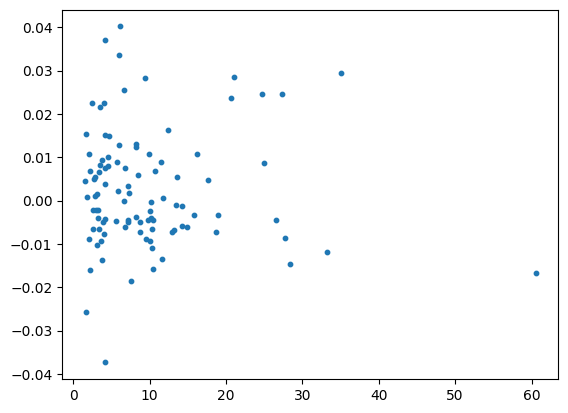

In [334]:
trades = processor.column_date_processing(trades[["date","abs","direction","std","ticker","GICS Sector","adjclose","return"]])

plt.scatter(trades["std"],trades["return"],s=10)
plt.show()


In [335]:
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio = portfolio[portfolio["date"]<portfolio["date"].max()]
portfolio = processor.merge(portfolio,benchmark,on="date").dropna()
portfolio["bcr"] = (portfolio["sp500"] - portfolio["sp500"].iloc[0]) / portfolio["sp500"].iloc[0] + 1
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()

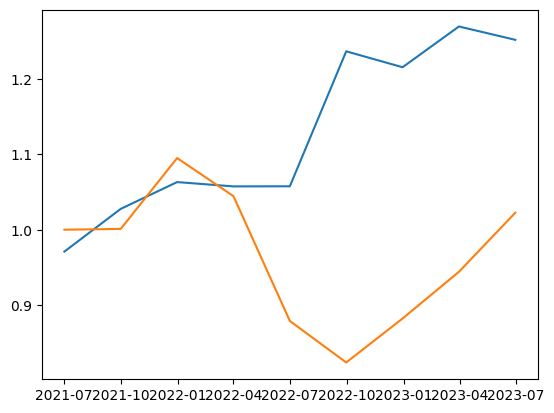

In [336]:
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.plot(portfolio["date"].values,portfolio["bcr"].values)
plt.show()

In [337]:
recommendations = trades.tail(positions)

In [338]:
recommendations

,date,abs,direction,std,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
99,2023-09-29 00:00:00+00:00,0.018446,1.0,25.466424,CHTR,Communication Services,439.820000,NaN,2023,3,9,39,4
100,2023-09-29 00:00:00+00:00,0.017431,1.0,6.331998,NKE,Consumer Discretionary,95.620000,NaN,2023,3,9,39,4
101,2023-09-29 00:00:00+00:00,0.028965,1.0,3.257997,WMT,Consumer Staples,159.930000,NaN,2023,3,9,39,4
102,2023-09-29 00:00:00+00:00,0.008937,1.0,5.023669,CVX,Energy,166.842947,NaN,2023,3,9,39,4
103,2023-09-29 00:00:00+00:00,0.045537,1.0,1.533293,AIG,Financials,60.600000,NaN,2023,3,9,39,4
104,2023-09-29 00:00:00+00:00,0.001605,1.0,17.030664,AMGN,Health Care,266.648619,NaN,2023,3,9,39,4
105,2023-09-29 00:00:00+00:00,0.000993,-1.0,5.927281,FDX,Industrials,264.920000,NaN,2023,3,9,39,4
106,2023-09-29 00:00:00+00:00,0.017692,1.0,21.634636,NVDA,Information Technology,434.990000,NaN,2023,3,9,39,4
107,2023-09-29 00:00:00+00:00,0.021909,1.0,6.778800,LIN,Materials,372.350000,NaN,2023,3,9,39,4
108,2023-09-29 00:00:00+00:00,0.070577,1.0,4.288664,SPG,Real Estate,108.030000,NaN,2023,3,9,39,4


In [339]:
db.connect()
db.drop('portfolios')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",trades)
db.store("recommendations",recommendations)
db.disconnect()